### Install and Import Libraries

In [2]:
# Install necessary packages
!pip install kagglehub tensorflow opencv-python matplotlib --quiet

# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

### Download Dataset from Kaggle

In [3]:
# Download wildfire dataset directly from Kaggle
dataset_path = kagglehub.dataset_download("elmadafri/the-wildfire-dataset")
print("Dataset downloaded at:", dataset_path)

# Check folder contents
print("Folders inside dataset:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'the-wildfire-dataset' dataset.
Dataset downloaded at: /kaggle/input/the-wildfire-dataset
Folders inside dataset: ['the_wildfire_dataset_2n_version']


### Preprocessing

In [4]:
# Data augmentation & preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [5]:
base_path = os.path.join(dataset_path, "the_wildfire_dataset_2n_version")
train_path = os.path.join(base_path, "train")
# Training data
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 1887 images belonging to 2 classes.


In [6]:
val_path = os.path.join(base_path, "val")
# Validation data
val_data = datagen.flow_from_directory(
    val_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)


Found 402 images belonging to 2 classes.


In [7]:
# Print class mapping
print("Class indices:", train_data.class_indices)

Class indices: {'fire': 0, 'nofire': 1}


### Visualize some sample images

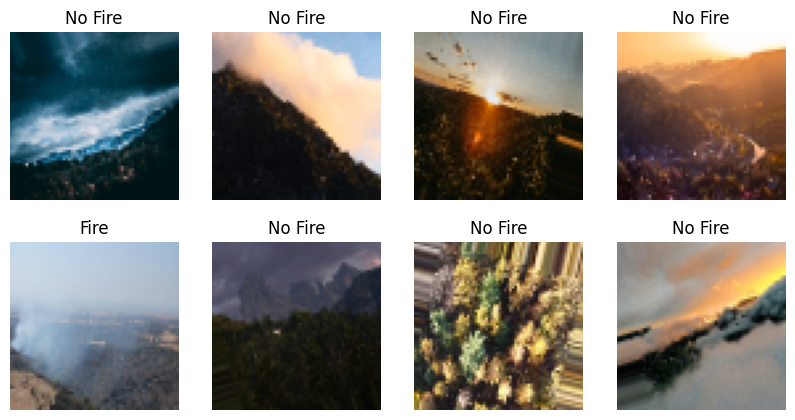

In [8]:
# Display sample images from training data
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title("No Fire" if labels[i]==1 else "Fire")
    plt.axis('off')
plt.show()

### Display Class Distribution

In [9]:
labels = train_data.classes

# Get class names
class_names = list(train_data.class_indices.keys())

# Count images per class
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"{class_names[i]}: {count} images")

fire: 730 images
nofire: 1157 images
